# Notebook 06: Evaluación Final a Gran Escala (220 Preguntas)

## 1. Objetivos del Cuaderno
Este notebook constituye la fase de validación a escala del Trabajo de Fin de Grado. Tras estabilizar la arquitectura y definir los 5 sistemas a comparar (SLM Base, LLM Avanzado A, LLM Avanzado B, RAG Léxico y RAG Semántico) en la prueba de concepto de 80 preguntas, el objetivo ahora es evaluar el sistema contra una batería de **140 preguntas nuevas**, alcanzando un total estadísticamente robusto de 220 iteraciones.

## 2. Metodología de Ejecución Optimizada
Para garantizar la estabilidad del sistema (evitando desbordamientos de memoria VRAM) y optimizar las peticiones a las APIs, la ejecución se ha compartimentado en bloques independientes:

1. **Filtrado del Dataset:** Se cargará la batería completa (`bateria_preguntas_tfg.csv`), pero el algoritmo omitirá automáticamente las primeras 80 iteraciones, ya que sus resultados consolidados y auditados residen de forma segura en `resultados_evaluacion_80_preguntas.csv`.
2. **Evaluación de Modelos Base (Sin RAG):** Se interrogará a Phi-3 (Local), Llama 3.3 70B (Nube) y Qwen 3 32B (Nube) operando de memoria. Para este último, se implementará un filtrado mediante expresiones regulares (`regex`) para eliminar su razonamiento interno (`<think>`) antes de la evaluación.
3. **Evaluación de Arquitecturas RAG:** En una celda independiente, se activarán los motores de búsqueda (BM25 y Vectorial BGE-M3) para alimentar de contexto a Phi-3.
4. **Tribunal Automático y Consolidación:** El modelo `gpt-oss-120b` actuará como juez estricto. Finalmente, las nuevas 140 filas se concatenarán con las 80 originales para generar el *dataset* definitivo: `resultados_evaluacion_5_modelos.csv`.
5. **Análisis Visual:** Generación de métricas y gráficos de rendimiento globales que permitirán dictaminar empíricamente qué combinación (Mejor RAG + Mejor LLM) avanzará a la fase final del proyecto.

In [1]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

import transformers
import warnings
import torch
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

# 1. Silenciamos avisos estándar y de Hugging Face
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# 2. Cargamos variables de entorno (API de Groq)
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    print("ADVERTENCIA: No se encontró GROQ_API_KEY en el entorno.")
else:
    print("API Key de Groq cargada correctamente.")

/home/javierruiz/miniconda3/envs/environment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


API Key de Groq cargada correctamente.


In [2]:
import gc
import torch
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

gc.collect()
torch.cuda.empty_cache()

# 1. Conexión a la base de datos (Túnel SSH activo)
print("Conectando a Elasticsearch...")
es = Elasticsearch("http://127.0.0.1:9250")
print("Ping a Elasticsearch:", es.ping())

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Carga del Modelo de Embeddings (BGE-M3)
print("Cargando BGE-M3 (Vectores)...")
embed_model = SentenceTransformer('BAAI/bge-m3', device=device)

# 3. Carga del Pequeño Modelo de Lenguaje (Phi-3)
print("Cargando Phi-3 (SLM)...")
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)

# Cargamos el modelo optimizado
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map="auto", torch_dtype=torch.float16)

# IMPORTANTE: No le pasamos el parámetro 'device' al pipeline porque device_map="auto" ya lo gestiona
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 4. Inyección en nuestro motor RAG personalizado
import rag_engine
rag_engine.es = es
rag_engine.embed_model = embed_model
rag_engine.pipe = pipe

print("Modelos locales cargados y enlazados a rag_engine.py exitosamente.")

Conectando a Elasticsearch...
Ping a Elasticsearch: True
Cargando BGE-M3 (Vectores)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3163.65it/s, Materializing param=pooler.dense.weight]                               


Cargando Phi-3 (SLM)...


Loading weights: 100%|██████████| 195/195 [00:03<00:00, 62.52it/s, Materializing param=model.norm.weight]                              


Sistema RAG (k=1) reconfigurado para devolver datos separados.
Sistema RAG Vectorial (k=1) configurado.
Modelos locales cargados y enlazados a rag_engine.py exitosamente.


In [3]:
# 1. LLM Avanzado A (Llama 3.3 70B)
llm_avanzado_a = ChatGroq(
    model="llama-3.3-70b-versatile", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

# 2. LLM Avanzado B (Qwen 3 32B - Grupo de Control)
llm_avanzado_b = ChatGroq(
    model="qwen/qwen3-32b", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

# 3. El Juez Estricto Autómata (GPT-OSS-120B)
llm_juez = ChatGroq(
    model="openai/gpt-oss-120b", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

prompt_evaluacion = ChatPromptTemplate.from_messages([
    ("system", """Eres un Juez de Veracidad para un sistema RAG. 
    Tu única misión es validar si la 'Respuesta Generada' coincide con la 'Respuesta Esperada'.

    REGLAS DE ORO:
    1. La respuesta generada puede ser CORRECTA aunque este redactada de forma diferente, siempre que transmita el mismo dato o información esencial que la respuesta esperada.
    2. No uses tu propio conocimiento externo para validar la respuesta, ciñete a la comparación entre la respuesta esperada y la generada.

    Responde ÚNICAMENTE con la palabra "CORRECTO" o "INCORRECTO"."""),
    ("human", "Respuesta Esperada:\n{esperada}\n\nRespuesta Generada por el RAG:\n{generada}")
])

juez_chain = prompt_evaluacion | llm_juez | StrOutputParser()

# Función de limpieza para eliminar el Chain of Thought de Qwen
def limpiar_think(texto):
    if isinstance(texto, str):
        return re.sub(r'<think>.*?</think>', '', texto, flags=re.DOTALL).strip()
    return texto

print("Modelos de la nube y sistema de Evaluación Juez configurados.")

Modelos de la nube y sistema de Evaluación Juez configurados.


In [6]:
# Cargamos la batería completa que acabamos de construir (220 preguntas)
df_preguntas_completas = pd.read_csv("bateria_preguntas_tfg.csv", sep = ";")
print(f"Batería total cargada: {len(df_preguntas_completas)} preguntas.")

# Cortamos el dataset: omitimos las 80 primeras (ya evaluadas)
# El índice 80 corresponde a la pregunta 81.
df_nuevas = df_preguntas_completas.iloc[80:].copy()
print(f"Preguntas a evaluar en esta sesión de estrés: {len(df_nuevas)}.")
df_nuevas.head(3)

Batería total cargada: 220 preguntas.
Preguntas a evaluar en esta sesión de estrés: 140.


,id,tipo,pregunta,respuesta_esperada
80,81,Factual,¿En qué fecha exacta se lanzó sin tripulación ...,El 16 de noviembre de 2022.
81,82,Factual,¿Para qué mes y año está previsto ahora el lan...,Para abril de 2026.
82,83,Factual,¿Qué modelo de trajes espaciales usarán los as...,Los trajes AxEMU.


In [ ]:
def caso1_slm_base(pregunta):
    messages = [
        {"role": "system", "content": "Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."},
        {"role": "user", "content": pregunta}
    ]
    out = pipe(messages, do_sample=False) 
    return out[0]['generated_text'][-1]['content'].strip()

def caso2_llm_avanzado_a(pregunta):
    messages = [
        SystemMessage(content="Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."),
        HumanMessage(content=pregunta)
    ]
    return llm_avanzado_a.invoke(messages).content.strip()

def caso2b_llm_avanzado_b(pregunta):
    messages = [
        SystemMessage(content="Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."),
        HumanMessage(content=pregunta)
    ]
    resp_bruta = llm_avanzado_b.invoke(messages).content.strip()
    return limpiar_think(resp_bruta) # Limpiamos la etiqueta <think>

resultados_fase1 = []
print("Iniciando Fase 1: Evaluación de conocimiento paramétrico (Sin RAG)...")

import gc # Recolector de basura

for index, row in tqdm(df_nuevas.iterrows(), total=len(df_nuevas)):
    pregunta = row['pregunta']
    esperada = row['respuesta_esperada']
    
    # 1. Generación simultánea
    resp_c1 = caso1_slm_base(pregunta)
    resp_c2 = caso2_llm_avanzado_a(pregunta)
    resp_c2b = caso2b_llm_avanzado_b(pregunta)
    
    # 2. Veredicto del Juez
    eval_c1 = juez_chain.invoke({"esperada": esperada, "generada": resp_c1}).strip().upper()
    eval_c2 = juez_chain.invoke({"esperada": esperada, "generada": resp_c2}).strip().upper()
    eval_c2b = juez_chain.invoke({"esperada": esperada, "generada": resp_c2b}).strip().upper()
    
    # 3. Almacenamiento con la misma nomenclatura del CSV antiguo
    resultados_fase1.append({
        "Pregunta": pregunta, "Esperada": esperada,
        "C1_SLM_Resp": resp_c1, "C1_Eval": eval_c1,
        "C2_LLM_Resp": resp_c2, "C2_Eval": eval_c2,
        "C2B_QWEN_Resp": resp_c2b, "C2B_Eval": eval_c2b
    })
    
    # Optimización de Hardware y Red
    time.sleep(1) 
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# PUNTO DE CONTROL (CHECKPOINT)
# ==========================================
df_fase1 = pd.DataFrame(resultados_fase1)
df_fase1.to_csv("checkpoint_fase1.csv", sep=';', index=False, encoding='utf-8-sig')
print("\n¡Fase 1 completada con éxito!")
print("Los resultados parciales se han guardado de forma segura en 'checkpoint_fase1.csv'.")
print("Puedes detener la ejecución del notebook aquí si lo necesitas.")

Iniciando Fase 1: Evaluación de conocimiento paramétrico (Sin RAG)...


100%|██████████| 140/140 [57:14<00:00, 24.53s/it]


¡Fase 1 completada con éxito!
Los resultados parciales se han guardado de forma segura en 'checkpoint_fase1.csv'.
Puedes detener la ejecución del notebook aquí si lo necesitas.


In [7]:
import pandas as pd
import os

# Comprobamos si existe el archivo de guardado intermedio
if os.path.exists("checkpoint_fase1.csv"):
    df_fase1 = pd.read_csv("checkpoint_fase1.csv", sep=';', encoding='utf-8')
    print(f"¡Checkpoint cargado exitosamente! Se han recuperado {len(df_fase1)} filas de la Fase 1.")
    print("Puedes continuar directamente con la ejecución de la Fase 2.")
    print(df_fase1.head(3))
else:
    print("No se ha encontrado el archivo 'checkpoint_fase1.csv'.")
    print("Asegúrate de haber ejecutado y completado la Celda 5 primero.")

¡Checkpoint cargado exitosamente! Se han recuperado 140 filas de la Fase 1.
Puedes continuar directamente con la ejecución de la Fase 2.
                                           ﻿Pregunta  \
0  ¿En qué fecha exacta se lanzó sin tripulación ...   
1  ¿Para qué mes y año está previsto ahora el lan...   
2  ¿Qué modelo de trajes espaciales usarán los as...   

                      Esperada  \
0  El 16 de noviembre de 2022.   
1          Para abril de 2026.   
2            Los trajes AxEMU.   

                                         C1_SLM_Resp     C1_Eval  \
0  La misión Artemis I de la NASA se lanzó sin tr...  INCORRECTO   
1  La misión Artemis II está previsto para su lan...  INCORRECTO   
2  Los astronautas de la misión Artemis III utili...  INCORRECTO   

                                         C2_LLM_Resp     C2_Eval  \
0                        El 16 de noviembre de 2022.    CORRECTO   
1                                 Noviembre de 2024.  INCORRECTO   
2  El traje espacial que

In [ ]:
def caso3_rag_bm25(pregunta):
    resultado = rag_engine.ask_rag(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

def caso4_rag_vectorial(pregunta):
    resultado = rag_engine.ask_rag_vectorial(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

resultados_fase2 = []
print("Iniciando Fase 2: Evaluación de motores de recuperación (RAG)...")

for index, row in tqdm(df_nuevas.iterrows(), total=len(df_nuevas)):
    pregunta = row['pregunta']
    esperada = row['respuesta_esperada']
    
    # 1. Recuperación y Generación
    resp_c3 = caso3_rag_bm25(pregunta)
    resp_c4 = caso4_rag_vectorial(pregunta)
    
    # 2. Veredicto del Juez
    eval_c3 = juez_chain.invoke({"esperada": esperada, "generada": resp_c3}).strip().upper()
    eval_c4 = juez_chain.invoke({"esperada": esperada, "generada": resp_c4}).strip().upper()
    
    resultados_fase2.append({
        "Pregunta": pregunta, "Esperada": esperada,
        "C3_BM25_Resp": resp_c3, "C3_Eval": eval_c3,
        "C4_VECT_Resp": resp_c4, "C4_Eval": eval_c4
    })
    
    # Optimización de Hardware y Red
    time.sleep(1) 
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# PUNTO DE CONTROL (CHECKPOINT)
# ==========================================
df_fase2 = pd.DataFrame(resultados_fase2)
df_fase2.to_csv("checkpoint_fase2.csv", sep=';', index=False, encoding='utf-8-sig')
print("\n¡Fase 2 completada con éxito!")
print("Los resultados de RAG se han guardado en 'checkpoint_fase2.csv'.")

In [10]:
#cargamos los checkpoints de ambas fases para consolidar el dataset final
df_fase1 = pd.read_csv("checkpoint_fase1.csv", sep=';', encoding='utf-8')
df_fase2 = pd.read_csv("checkpoint_fase2.csv", sep=';', encoding='utf-8')
# 1. Unimos horizontalmente las columnas de la Fase 1 con las ultimas 4 columnas de la fase 2
df_nuevas_evaluadas = pd.concat([df_fase1, df_fase2.iloc[:, -4:]], axis=1)

# 2. Cargamos el dataset histórico perfectamente evaluado (primeras 80)
df_historico = pd.read_csv("resultados_evaluacion_80_preguntas.csv", sep=';')

# 3. Concatenamos verticalmente (80 antiguas + 140 nuevas = 220 totales)
df_final_5_modelos = pd.concat([df_historico, df_nuevas_evaluadas], ignore_index=True)

# 4. Guardamos la joya de la corona del TFG
ruta_final = "resultados_evaluacion_5_modelos.csv"
df_final_5_modelos.to_csv(ruta_final, sep=';', index=False, encoding='utf-8-sig')

print(f"Dataset masivo de {len(df_final_5_modelos)} iteraciones guardado en '{ruta_final}'.\n")

# 5. Resumen preliminar
aciertos = {
    "1. SLM Base (Phi-3)": (df_final_5_modelos['C1_Eval'] == 'CORRECTO').sum(),
    "2. LLM Avanzado A (Llama 3.3)": (df_final_5_modelos['C2_Eval'] == 'CORRECTO').sum(),
    "3. Grupo Control (Qwen 3)": (df_final_5_modelos['C2B_Eval'] == 'CORRECTO').sum(),
    "4. RAG Léxico (BM25)": (df_final_5_modelos['C3_Eval'] == 'CORRECTO').sum(),
    "5. RAG Semántico (Vectores)": (df_final_5_modelos['C4_Eval'] == 'CORRECTO').sum()
}

print("=== DIAGNÓSTICO PRELIMINAR DE RENDIMIENTO (SOBRE 220 PREGUNTAS) ===")
for nombre, valor in aciertos.items():
    print(f"{nombre}: {valor} aciertos ({(valor/220)*100:.1f}%)")

Dataset masivo de 220 iteraciones guardado en 'resultados_evaluacion_5_modelos.csv'.

=== DIAGNÓSTICO PRELIMINAR DE RENDIMIENTO (SOBRE 220 PREGUNTAS) ===
1. SLM Base (Phi-3): 36 aciertos (16.4%)
2. LLM Avanzado A (Llama 3.3): 65 aciertos (29.5%)
3. Grupo Control (Qwen 3): 54 aciertos (24.5%)
4. RAG Léxico (BM25): 99 aciertos (45.0%)
5. RAG Semántico (Vectores): 156 aciertos (70.9%)


Generando gráfico para 220 preguntas evaluadas.
Gráfico guardado exitosamente como 'grafico_rendimiento_220_preguntas.png'


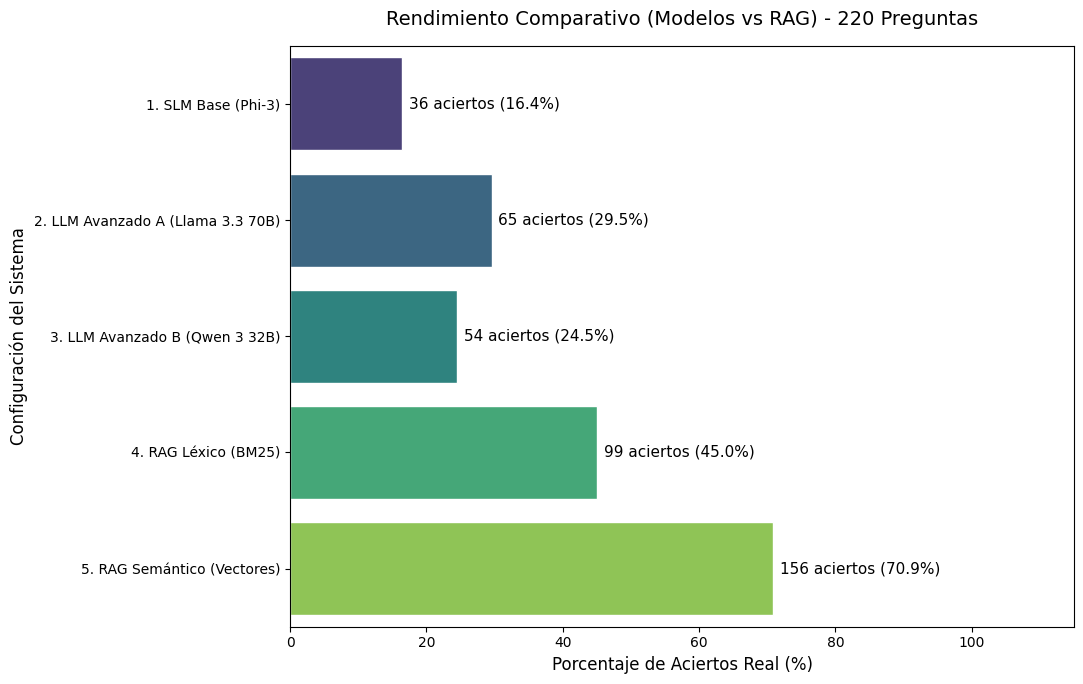

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el CSV final ampliado a 220 preguntas
ruta_final = "resultados_evaluacion_5_modelos.csv"
df_final = pd.read_csv(ruta_final, sep=';', encoding='utf-8-sig')
df_final.columns = df_final.columns.str.strip()

print(f"Generando gráfico para {len(df_final)} preguntas evaluadas.")

# 2. Contar los aciertos de los 5 sistemas
aciertos = {
    "1. SLM Base (Phi-3)": (df_final['C1_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "2. LLM Avanzado A (Llama 3.3 70B)": (df_final['C2_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "3. LLM Avanzado B (Qwen 3 32B)": (df_final['C2B_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "4. RAG Léxico (BM25)": (df_final['C3_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "5. RAG Semántico (Vectores)": (df_final['C4_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum()
}

# 3. Preparar los datos
nombres = list(aciertos.keys())
valores = list(aciertos.values())
total_preguntas = len(df_final)
porcentajes = [(v / total_preguntas) * 100 for v in valores]

# 4. Crear el gráfico
fig, ax = plt.subplots(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# Añadimos hue=nombres y legend=False para mantener las barras de colores sin warnings
sns.barplot(x=porcentajes, y=nombres, hue=nombres, palette="viridis", legend=False, ax=ax)

# Etiquetas de datos
for p, val, perc in zip(ax.patches, valores, porcentajes):
    ax.annotate(f"{val} aciertos ({perc:.1f}%)", 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, 115) # Ampliado ligeramente el límite para que los textos largos no se corten
plt.title(f'Rendimiento Comparativo (Modelos vs RAG) - {total_preguntas} Preguntas', fontsize=14, pad=15)
plt.xlabel('Porcentaje de Aciertos Real (%)', fontsize=12)
plt.ylabel('Configuración del Sistema', fontsize=12)
plt.tight_layout()

# 5. Guardar la imagen con el nuevo nombre
nombre_imagen = "grafico_rendimiento_220_preguntas.png"
plt.savefig(nombre_imagen, dpi=300)
print(f"Gráfico guardado exitosamente como '{nombre_imagen}'")